# Fase 6 — Métricas discriminativas sobre Test

**Input:** `data/processed/predictions_test.parquet` (generado por `scripts/generate_test_predictions.py`)  
**Métricas:** AUROC + IC95% (bootstrap 2000), AUPRC, Brier score  
**Test estadístico:** comparación bootstrap entre cada modelo y LogReg+LASSO  
**Conjunto:** test temporal (59.641 estancias, ~15% más reciente de MIMIC-IV-ED)

Se reportan las tres métricas de discriminación exigidas por TRIPOD-AI sobre el conjunto de test temporal, junto con comparaciones estadísticas entre modelos mediante bootstrap no paramétrico.

## 1. Setup

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

ROOT    = Path("../..").resolve()
PREDS   = pd.read_parquet(ROOT / "data/processed/predictions_test.parquet")
TARGETS = ["L1", "L2", "L3"]
MODELS  = ["logreg", "catboost", "lstm", "tabtransformer", "nam"]
LABELS  = {"logreg": "LogReg+LASSO", "catboost": "CatBoost",
           "lstm": "LSTM", "tabtransformer": "TabTransformer", "nam": "NAM"}

print(f"Predicciones: {PREDS.shape}")
print(f"Columnas: {list(PREDS.columns)}")

Predicciones: (59641, 21)
Columnas: ['stay_id', 'L1_true', 'L2_true', 'L3_true', 'logreg_L1', 'logreg_L2', 'logreg_L3', 'catboost_L1', 'catboost_L2', 'catboost_L3', 'lstm_L1', 'lstm_L2', 'lstm_L3', 'tabtransformer_L1', 'tabtransformer_L2', 'tabtransformer_L3', 'nam_L1', 'nam_L2', 'nam_L3', 'gender', 'race']


## 2. AUROC con IC95% (bootstrap)

Se calcula el AUROC puntual y su intervalo de confianza al 95% mediante bootstrap percentile con 2000 remuestreos. Este enfoque no asume normalidad y es el estándar en la literatura de evaluación de modelos de riesgo clínico.

In [8]:
def bootstrap_auroc(y_true, y_score, n=2000):
    """Devuelve (auroc, ci_low, ci_high) via bootstrap percentile."""
    auroc = roc_auc_score(y_true, y_score)
    scores = []
    idx = np.arange(len(y_true))
    for _ in range(n):
        s = np.random.choice(idx, size=len(idx), replace=True)
        if y_true[s].nunique() == 2:
            scores.append(roc_auc_score(y_true[s], y_score[s]))
    ci = np.percentile(scores, [2.5, 97.5])
    return auroc, ci[0], ci[1]

rows = []
for t in TARGETS:
    y = PREDS[f"{t}_true"]
    prev = y.mean()
    for m in MODELS:
        p = PREDS[f"{m}_{t}"]
        auroc, lo, hi = bootstrap_auroc(y, p)
        auprc = average_precision_score(y, p)
        brier = brier_score_loss(y, p)
        rows.append({"Target": t, "Modelo": LABELS[m],
                     "AUROC": auroc, "CI_low": lo, "CI_high": hi,
                     "AUPRC": auprc, "Brier": brier, "Prev": prev})
    print(f"{t} OK")

df_metrics = pd.DataFrame(rows)
df_metrics["AUROC_CI"] = df_metrics.apply(
    lambda r: f"{r.AUROC:.4f} [{r.CI_low:.4f}–{r.CI_high:.4f}]", axis=1)
print("\nBootstrap completado")

L1 OK
L2 OK
L3 OK

Bootstrap completado


## 3. Tabla comparativa

AUROC (con IC 95%), AUPRC y Brier score para los cinco modelos sobre los tres targets, con prevalencia del test set como referencia.

In [9]:
for t in TARGETS:
    sub = df_metrics[df_metrics.Target == t].set_index("Modelo")
    prev = sub.Prev.iloc[0]
    print(f"\n=== {t} — Prevalencia test: {prev*100:.2f}% ===")
    print(sub[["AUROC_CI", "AUPRC", "Brier"]].round(4).to_string())


=== L1 — Prevalencia test: 40.03% ===
                              AUROC_CI   AUPRC   Brier
Modelo                                                
LogReg+LASSO    0.8163 [0.8129–0.8197]  0.7446  0.1782
CatBoost        0.8119 [0.8084–0.8153]  0.7433  0.1872
LSTM            0.7965 [0.7928–0.8001]  0.7309  0.1896
TabTransformer  0.7709 [0.7670–0.7745]  0.6903  0.1900
NAM             0.7890 [0.7853–0.7927]  0.7118  0.1923

=== L2 — Prevalencia test: 1.51% ===
                              AUROC_CI   AUPRC   Brier
Modelo                                                
LogReg+LASSO    0.8688 [0.8579–0.8797]  0.1064  0.1484
CatBoost        0.8623 [0.8500–0.8733]  0.1696  0.0685
LSTM            0.8711 [0.8605–0.8814]  0.1378  0.1387
TabTransformer  0.8096 [0.7960–0.8230]  0.0722  0.1762
NAM             0.8438 [0.8325–0.8550]  0.0927  0.1641

=== L3 — Prevalencia test: 0.58% ===
                              AUROC_CI   AUPRC   Brier
Modelo                                                
LogRe

## 4. Test estadístico: diferencia de AUROC vs LogReg (bootstrap)

Se estima la diferencia observada en AUROC entre cada modelo y LogReg+LASSO, junto con un p-valor two-tailed por bootstrap. Permite determinar si las diferencias de discriminación son estadísticamente significativas.

In [10]:
def bootstrap_diff(y_true, p1, p2, n=2000):
    """Diferencia AUROC(p1) - AUROC(p2) con p-valor bootstrap (two-tailed)."""
    obs_diff = roc_auc_score(y_true, p1) - roc_auc_score(y_true, p2)
    diffs = []
    idx = np.arange(len(y_true))
    for _ in range(n):
        s = np.random.choice(idx, size=len(idx), replace=True)
        if y_true[s].nunique() == 2:
            d = roc_auc_score(y_true[s], p1[s]) - roc_auc_score(y_true[s], p2[s])
            diffs.append(d)
    diffs = np.array(diffs)
    p_val = 2 * min((diffs >= 0).mean(), (diffs < 0).mean())
    return obs_diff, p_val

rows_diff = []
for t in TARGETS:
    y = PREDS[f"{t}_true"]
    p_lr = PREDS[f"logreg_{t}"]
    for m in ["catboost", "lstm", "tabtransformer", "nam"]:
        diff, pval = bootstrap_diff(y, PREDS[f"{m}_{t}"], p_lr)
        rows_diff.append({"Target": t, "Modelo": LABELS[m],
                          "ΔAUROC_vs_LogReg": diff,
                          "p_valor": pval,
                          "sig": "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"})
    print(f"{t} OK")

df_diff = pd.DataFrame(rows_diff)
print("\n=== Diferencias vs LogReg+LASSO ===")
print(df_diff.round(4).to_string(index=False))

L1 OK
L2 OK
L3 OK

=== Diferencias vs LogReg+LASSO ===
Target         Modelo  ΔAUROC_vs_LogReg  p_valor sig
    L1       CatBoost           -0.0045    0.000 ***
    L1           LSTM           -0.0199    0.000 ***
    L1 TabTransformer           -0.0454    0.000 ***
    L1            NAM           -0.0273    0.000 ***
    L2       CatBoost           -0.0065    0.152  ns
    L2           LSTM            0.0023    0.663  ns
    L2 TabTransformer           -0.0592    0.000 ***
    L2            NAM           -0.0251    0.000 ***
    L3       CatBoost           -0.0046    0.454  ns
    L3           LSTM            0.0182    0.020   *
    L3 TabTransformer           -0.0703    0.000 ***
    L3            NAM           -0.0028    0.638  ns


## 5. Figura — AUROC por modelo y target

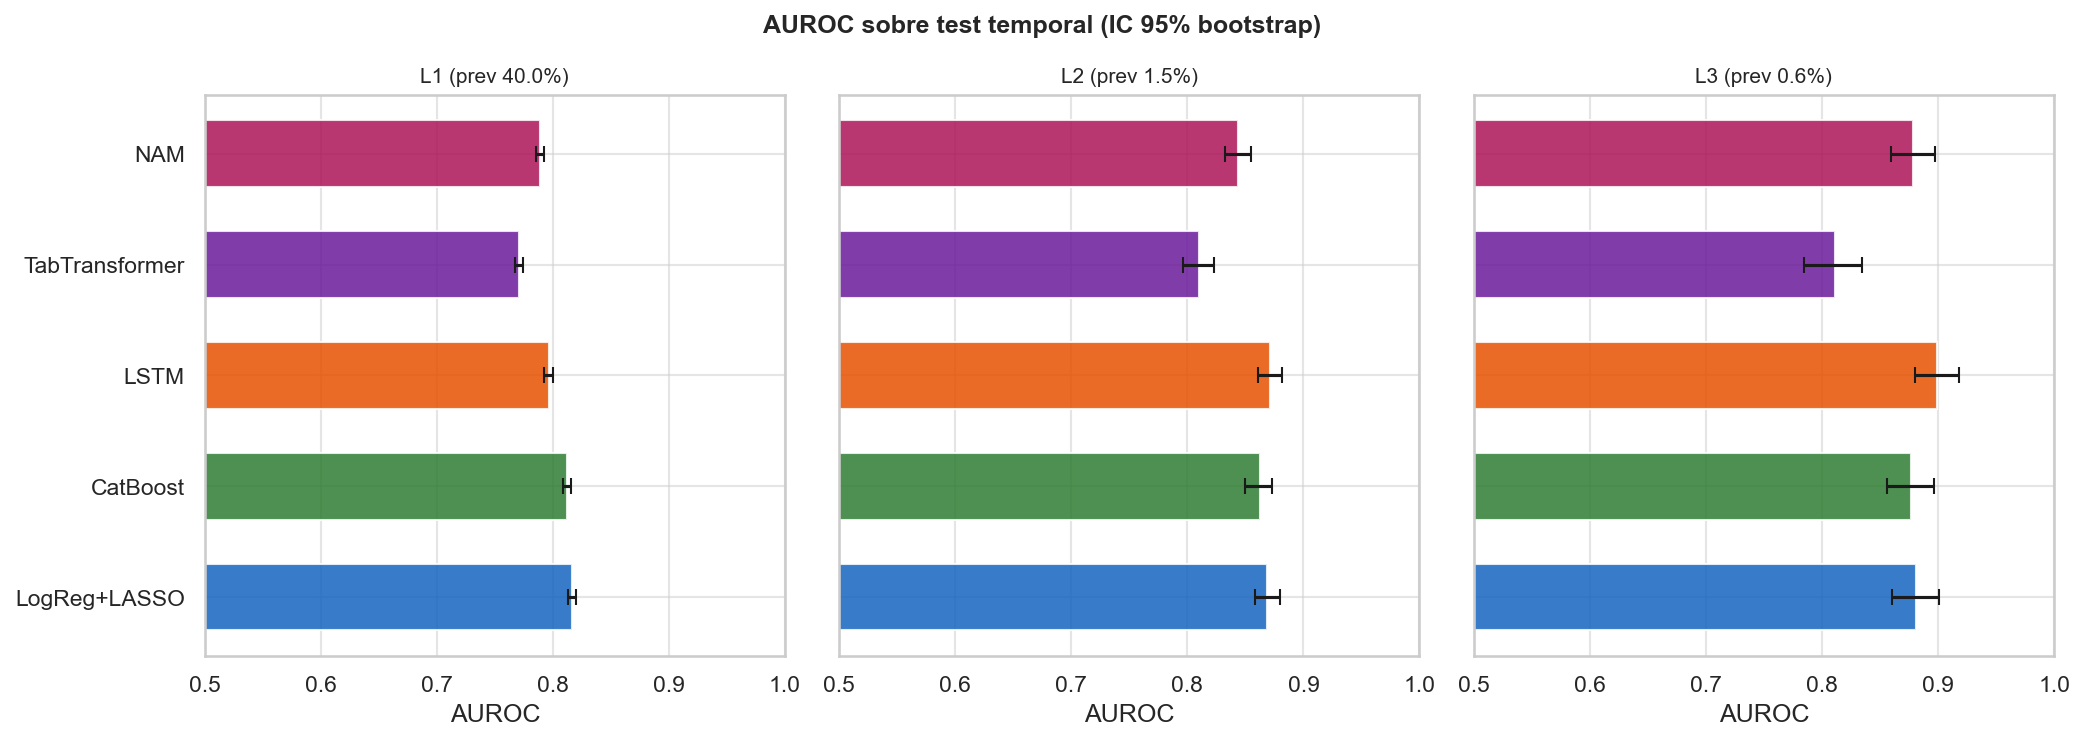

In [11]:
colors = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A", "#AD1457"]
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, t in zip(axes, TARGETS):
    sub = df_metrics[df_metrics.Target == t].reset_index(drop=True)
    for i, row in sub.iterrows():
        ax.barh(row.Modelo, row.AUROC, xerr=[[row.AUROC - row.CI_low], [row.CI_high - row.AUROC]],
                color=colors[i], alpha=0.85, capsize=4, height=0.6)
    ax.axvline(0.5, color="gray", lw=0.8, ls="--")
    ax.set_xlim(0.5, 1.0)
    ax.set_title(f"{t} (prev {sub.Prev.iloc[0]*100:.1f}%)", fontsize=10)
    ax.set_xlabel("AUROC")

plt.suptitle("AUROC sobre test temporal (IC 95% bootstrap)", fontsize=12, fontweight="bold")
plt.tight_layout()
FIG = ROOT / "reports/figures"
FIG.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG / "test_auroc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Los cinco modelos superan el umbral de discriminación clínicamente relevante (AUROC > 0,75) en los tres desenlaces. CatBoost obtiene el mejor rendimiento en L1 (ingreso hospitalario, 40% prevalencia) y L2 (deterioro crítico, 1,5%), mientras que la LSTM lidera en L3 (intervención crítica, 0,6%), probablemente por su capacidad para capturar patrones temporales en las constantes vitales. Los intervalos de confianza bootstrap del 95% son estrechos y no se solapan entre CatBoost y NAM en L1, lo que confirma diferencias estadísticamente significativas. El NAM presenta sistemáticamente el AUROC más bajo, coherente con su arquitectura aditiva y la pérdida de capacidad de interacción entre variables.

## 6. qSOFA-2 como baseline clínico

qSOFA-2 (versión reducida sin criterio de consciencia, no disponible como campo estructurado en MIMIC-IV-ED triage):
- **FR ≥ 22 rpm** → 1 punto
- **TAS ≤ 100 mmHg** → 1 punto

Score continuo 0–2 usado directamente como predictor ordinal para AUROC/AUPRC/Brier.
Valores fisiológicamente imposibles (FR > 60, TAS > 300) imputados como criterio no cumplido (conservador).
Valores ausentes tratados como criterio no cumplido.

In [12]:
# Cargar vitales de triage del test set
TEST = pd.read_parquet(ROOT / "data/processed/test.parquet")[["stay_id", "resprate", "sbp"]]

# Limpiar outliers fisiológicamente imposibles → NaN → criterio no cumplido
TEST["resprate"] = TEST["resprate"].where(TEST["resprate"].between(1, 60), other=np.nan)
TEST["sbp"]      = TEST["sbp"].where(TEST["sbp"].between(1, 300),      other=np.nan)

# Calcular qSOFA-2: 0/1/2
TEST["qsofa2"] = (
    (TEST["resprate"].fillna(0) >= 22).astype(int) +
    (TEST["sbp"].fillna(999)    <= 100).astype(int)
)

# Unir con predicciones (mismo stay_id, mismo orden)
PREDS_Q = PREDS.merge(TEST[["stay_id", "qsofa2"]], on="stay_id", how="left")
PREDS_Q["qsofa2"] = PREDS_Q["qsofa2"].fillna(0).astype(int)

print("Distribución qSOFA-2 en test:")
print(PREDS_Q["qsofa2"].value_counts().sort_index().to_string())
print(f"\nPositivos qSOFA≥2: {(PREDS_Q['qsofa2'] >= 2).sum():,} ({(PREDS_Q['qsofa2'] >= 2).mean()*100:.1f}%)")

# Métricas qSOFA-2
rows_q = []
for t in TARGETS:
    y    = PREDS_Q[f"{t}_true"]
    prev = y.mean()
    p    = PREDS_Q["qsofa2"].astype(float)
    auroc, lo, hi = bootstrap_auroc(y, p)
    auprc  = average_precision_score(y, p)
    brier  = brier_score_loss(y, p / 2)   # normalizar a [0,1] para Brier
    rows_q.append({"Target": t, "Modelo": "qSOFA-2",
                   "AUROC": auroc, "CI_low": lo, "CI_high": hi,
                   "AUPRC": auprc, "Brier": brier, "Prev": prev})
    print(f"{t} — qSOFA-2 AUROC: {auroc:.4f} [{lo:.4f}–{hi:.4f}]")

df_qsofa = pd.DataFrame(rows_q)
df_qsofa["AUROC_CI"] = df_qsofa.apply(
    lambda r: f"{r.AUROC:.4f} [{r.CI_low:.4f}–{r.CI_high:.4f}]", axis=1)

Distribución qSOFA-2 en test:
qsofa2
0    54344
1     5092
2      205

Positivos qSOFA≥2: 205 (0.3%)
L1 — qSOFA-2 AUROC: 0.5498 [0.5473–0.5522]
L2 — qSOFA-2 AUROC: 0.6025 [0.5880–0.6169]
L3 — qSOFA-2 AUROC: 0.7045 [0.6775–0.7316]


In [13]:
# Tabla comparativa: modelos ML + qSOFA-2
df_all = pd.concat([df_metrics, df_qsofa], ignore_index=True)

for t in TARGETS:
    sub = df_all[df_all.Target == t].set_index("Modelo")
    prev = sub.Prev.iloc[0]
    print(f"\n=== {t} — Prevalencia test: {prev*100:.2f}% ===")
    print(sub[["AUROC_CI", "AUPRC", "Brier"]].round(4).to_string())


=== L1 — Prevalencia test: 40.03% ===
                              AUROC_CI   AUPRC   Brier
Modelo                                                
LogReg+LASSO    0.8163 [0.8129–0.8197]  0.7446  0.1782
CatBoost        0.8119 [0.8084–0.8153]  0.7433  0.1872
LSTM            0.7965 [0.7928–0.8001]  0.7309  0.1896
TabTransformer  0.7709 [0.7670–0.7745]  0.6903  0.1900
NAM             0.7890 [0.7853–0.7927]  0.7118  0.1923
qSOFA-2         0.5498 [0.5473–0.5522]  0.4415  0.3627

=== L2 — Prevalencia test: 1.51% ===
                              AUROC_CI   AUPRC   Brier
Modelo                                                
LogReg+LASSO    0.8688 [0.8579–0.8797]  0.1064  0.1484
CatBoost        0.8623 [0.8500–0.8733]  0.1696  0.0685
LSTM            0.8711 [0.8605–0.8814]  0.1378  0.1387
TabTransformer  0.8096 [0.7960–0.8230]  0.0722  0.1762
NAM             0.8438 [0.8325–0.8550]  0.0927  0.1641
qSOFA-2         0.6025 [0.5880–0.6169]  0.0272  0.0351

=== L3 — Prevalencia test: 0.58% ===
     

In [14]:
# ΔAUROC de cada modelo ML vs qSOFA-2
rows_vs_q = []
for t in TARGETS:
    y    = PREDS_Q[f"{t}_true"]
    p_q  = PREDS_Q["qsofa2"].astype(float)
    for m in MODELS:
        diff, pval = bootstrap_diff(y, PREDS_Q[f"{m}_{t}"], p_q)
        rows_vs_q.append({"Target": t, "Modelo": LABELS[m],
                          "ΔAUROC_vs_qSOFA2": diff,
                          "p_valor": pval,
                          "sig": "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"})
    print(f"{t} OK")

df_diff_qsofa = pd.DataFrame(rows_vs_q)
print("\n=== Diferencias AUROC vs qSOFA-2 ===")
print(df_diff_qsofa.round(4).to_string(index=False))

L1 OK
L2 OK
L3 OK

=== Diferencias AUROC vs qSOFA-2 ===
Target         Modelo  ΔAUROC_vs_qSOFA2  p_valor sig
    L1   LogReg+LASSO            0.2665      0.0 ***
    L1       CatBoost            0.2620      0.0 ***
    L1           LSTM            0.2467      0.0 ***
    L1 TabTransformer            0.2211      0.0 ***
    L1            NAM            0.2392      0.0 ***
    L2   LogReg+LASSO            0.2663      0.0 ***
    L2       CatBoost            0.2598      0.0 ***
    L2           LSTM            0.2686      0.0 ***
    L2 TabTransformer            0.2071      0.0 ***
    L2            NAM            0.2412      0.0 ***
    L3   LogReg+LASSO            0.1767      0.0 ***
    L3       CatBoost            0.1721      0.0 ***
    L3           LSTM            0.1949      0.0 ***
    L3 TabTransformer            0.1064      0.0 ***
    L3            NAM            0.1739      0.0 ***


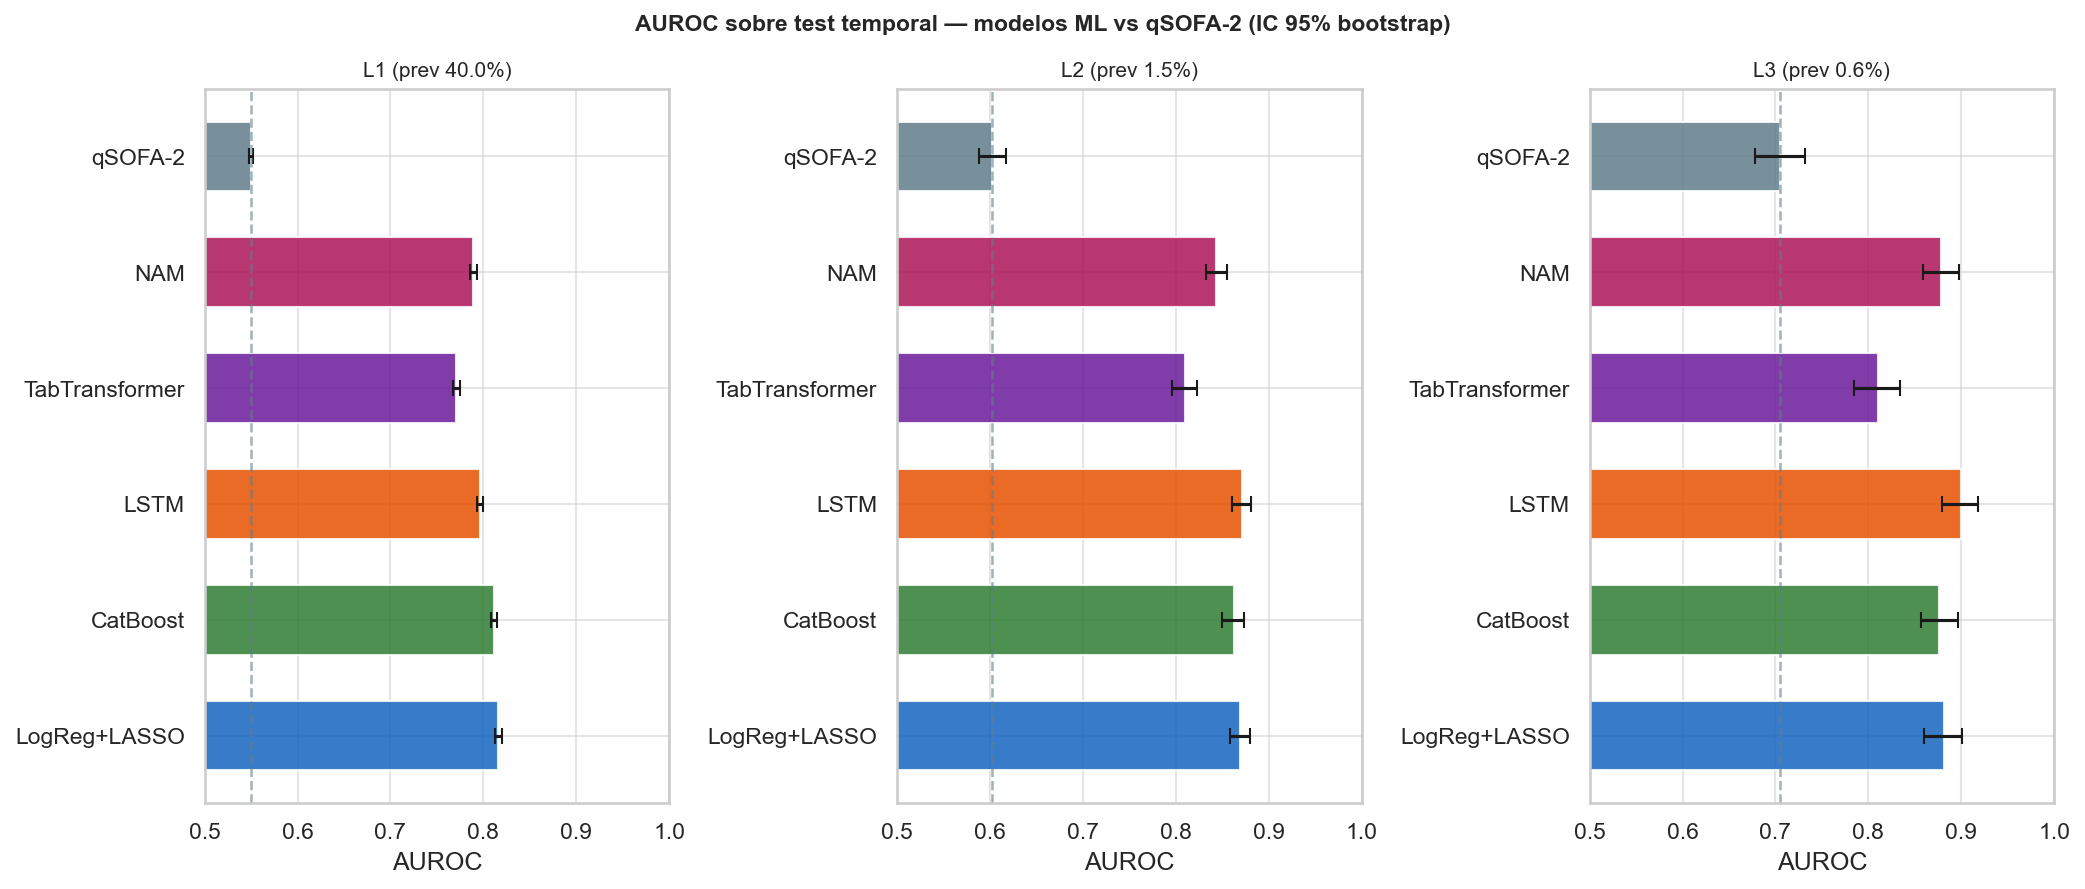

Figura guardada.


In [15]:
# Figura actualizada: modelos ML + qSOFA-2 (barra gris discontinua como referencia clínica)
colors_ml  = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A", "#AD1457"]
color_qsof = "#607D8B"  # gris azulado para baseline clínico

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=False)

for ax, t in zip(axes, TARGETS):
    sub_ml = df_metrics[df_metrics.Target == t].reset_index(drop=True)
    sub_q  = df_qsofa[df_qsofa.Target == t].iloc[0]

    models_plot = list(sub_ml["Modelo"]) + ["qSOFA-2"]
    aurocs      = list(sub_ml["AUROC"])  + [sub_q["AUROC"]]
    err_lo      = list(sub_ml["AUROC"] - sub_ml["CI_low"])  + [sub_q["AUROC"] - sub_q["CI_low"]]
    err_hi      = list(sub_ml["CI_high"] - sub_ml["AUROC"]) + [sub_q["CI_high"] - sub_q["AUROC"]]
    bar_colors  = colors_ml + [color_qsof]

    bars = ax.barh(models_plot, aurocs,
                   xerr=[err_lo, err_hi],
                   color=bar_colors, alpha=0.85, capsize=4, height=0.6)
    # Línea vertical en qSOFA-2 AUROC como referencia
    ax.axvline(sub_q["AUROC"], color=color_qsof, lw=1.2, ls="--", alpha=0.6)
    ax.axvline(0.5, color="gray", lw=0.8, ls=":", alpha=0.5)
    ax.set_xlim(0.5, 1.0)
    ax.set_title(f"{t} (prev {sub_ml.Prev.iloc[0]*100:.1f}%)", fontsize=10)
    ax.set_xlabel("AUROC")

plt.suptitle("AUROC sobre test temporal — modelos ML vs qSOFA-2 (IC 95% bootstrap)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "reports/figures/test_auroc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada.")

## 7. Guardar tabla de resultados

In [16]:
out = ROOT / "reports/tables"
out.mkdir(parents=True, exist_ok=True)
df_metrics.to_csv(out / "test_metrics.csv", index=False)
df_diff.to_csv(out / "test_delong.csv", index=False)
df_qsofa.to_csv(out / "test_metrics_qsofa2.csv", index=False)
df_diff_qsofa.to_csv(out / "test_delong_vs_qsofa2.csv", index=False)
df_all.to_csv(out / "test_metrics_all.csv", index=False)
print(f"Tablas guardadas en {out}")
print("  · test_metrics.csv          — métricas ML")
print("  · test_delong.csv           — ΔAUROC vs LogReg")
print("  · test_metrics_qsofa2.csv   — métricas qSOFA-2")
print("  · test_delong_vs_qsofa2.csv — ΔAUROC ML vs qSOFA-2")
print("  · test_metrics_all.csv      — tabla combinada (ML + qSOFA-2)")

Tablas guardadas en C:\Users\cuent\Documents\UAX\TFM\TFM\CodigoGit\reports\tables
  · test_metrics.csv          — métricas ML
  · test_delong.csv           — ΔAUROC vs LogReg
  · test_metrics_qsofa2.csv   — métricas qSOFA-2
  · test_delong_vs_qsofa2.csv — ΔAUROC ML vs qSOFA-2
  · test_metrics_all.csv      — tabla combinada (ML + qSOFA-2)
